In [1]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI ML/Data/Copy of devnagari digit.zip'
extraction_path = '/content/devnagari_digit_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset extracted to: {extraction_path}")
print(f"Contents of the extracted directory: {os.listdir(extraction_path)}")

Dataset extracted to: /content/devnagari_digit_dataset
Contents of the extracted directory: ['DevanagariHandwrittenDigitDataset']


In [5]:
# Import necessary libraries for numerical operations, deep learning, and visualization
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [6]:
# Load MNIST handwritten digit dataset (already split into training and testing)
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [7]:
# Normalize pixel values from range [0,255] to [0,1] for better training performance
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
# Flatten 28x28 images into 1D vectors of size 784 (required for fully connected network)
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

In [9]:
# Convert labels into one-hot encoded format (e.g., 3 → [0,0,0,1,0,...])
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [10]:
# Build a Fully Connected Neural Network using Sequential API
model = tf.keras.Sequential([

    # Input layer (784 features from flattened image)
    layers.Input(shape=(784,)),

    # Hidden layer with 64 neurons and sigmoid activation
    layers.Dense(64, activation='sigmoid'),

    # Hidden layer with 128 neurons
    layers.Dense(128, activation='sigmoid'),

    # Hidden layer with 256 neurons
    layers.Dense(256, activation='sigmoid'),

    # Output layer with 10 neurons (for digits 0–9) using softmax
    layers.Dense(10, activation='softmax')
])

In [11]:
# Display model architecture, layers, and number of parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile the model by specifying optimizer, loss function, and evaluation metric
model.compile(
    optimizer='sgd',                    # Stochastic Gradient Descent optimizer
    loss='categorical_crossentropy',   # Loss function for multi-class classification
    metrics=['accuracy']               # Track accuracy during training
)

In [13]:
# Train the model on training data
history = model.fit(
    x_train,                # Training input data
    y_train,                # Training labels
    batch_size=128,         # Number of samples per batch
    epochs=20,              # Number of training iterations
    validation_split=0.15   # Use 15% of training data for validation
)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1081 - loss: 2.3043 - val_accuracy: 0.1063 - val_loss: 2.3042
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1152 - loss: 2.3003 - val_accuracy: 0.1028 - val_loss: 2.3018
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1160 - loss: 2.2991 - val_accuracy: 0.1063 - val_loss: 2.2999
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1173 - loss: 2.2973 - val_accuracy: 0.1063 - val_loss: 2.2965
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1237 - loss: 2.2958 - val_accuracy: 0.1063 - val_loss: 2.2949
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1258 - loss: 2.2939 - val_accuracy: 0.1063 - val_loss: 2.2934
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1261 - loss: 2.2919 - val_accuracy: 0.1063 - val_loss: 2.2913
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1364 - loss: 2.2893 - val_accuracy: 0.

In [14]:
# Evaluate model performance on unseen test data
test_loss, test_acc = model.evaluate(x_test, y_test)

# Print test accuracy
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3945 - loss: 2.1520
Test Accuracy: 0.3944999873638153


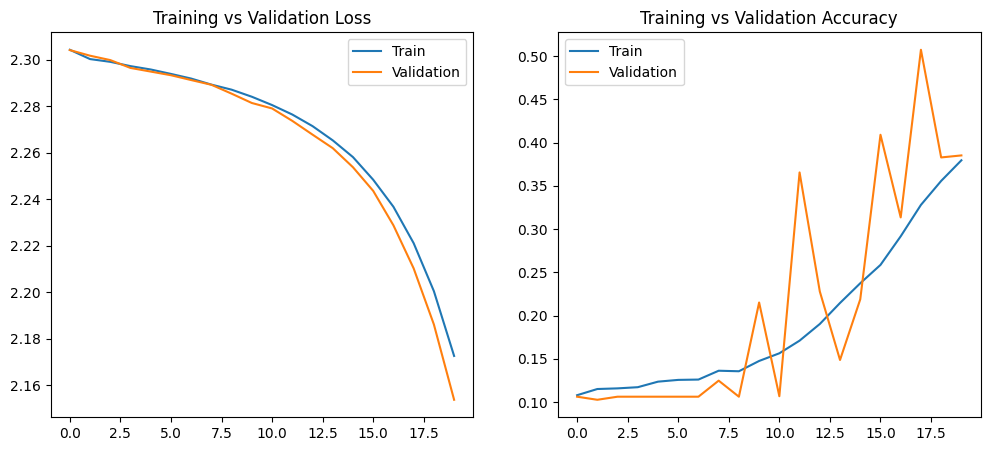

In [15]:
# Extract training and validation metrics from history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Create plots to visualize performance
plt.figure(figsize=(12, 5))

# Plot Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Training vs Validation Loss")
plt.legend(["Train", "Validation"])

# Plot Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_acc)
plt.plot(val_acc)
plt.title("Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

In [16]:
# Make predictions on test data
predictions = model.predict(x_test)

# Display prediction vs actual for first test sample
print("Predicted:", np.argmax(predictions[0]))
print("Actual:", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted: 7
Actual: 7
